# FCC-ee Impedance/Wake Model

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.ticker import LogLocator

## Impedance/Wake (I/W) Model plotting : more info in readme

### Reading of device impedance from Impedance folder

In [2]:
def read_impedance_devices(folder, plane):
    """
    Read impedance files from Devices folder.
    Returns
    -------
    freq : array
    devices : dict {device_name : complex impedance}
    """
    devices = {}

    files = sorted(folder.glob(f"Z_*_{plane}.txt"))

    for f in files:

        data = np.loadtxt(f, skiprows=1)

        freq = data[:,0]
        Z = data[:,1] + 1j*data[:,2]

        name = f.stem.replace(f"_"+plane,"").replace("Z_","")

        devices[name] = Z

    return freq, devices

def read_total_impedance(folder, plane):
    
    file = Path(folder) / f"Z_tot_{plane}.txt"

    data = np.loadtxt(file, comments="#")

    freq = data[:,0]
    Z = data[:,1] + 1j*data[:,2]

    return freq, Z

### Colour Plot of impedance device contribution

In [3]:
def plot_stacked_impedance(frequency, Z_contributions, labels, colors,
                          plane="dipy", part="imag"):

    plane_label_map = {
        "dipx": r"$Z_{x}$",
        "dipy": r"$Z_{y}$",
        "long": r"$Z_{long}$"
    }

    unit_map = {
        "dipx": r"($\Omega$/m)",
        "dipy": r"($\Omega$/m)",
        "long": r"($\Omega$)"
    }

    part_label_map = {
        "real": "Re",
        "imag": "Im"
    }

    part_name_map = {
        "real": "Re",
        "imag": "Im"
    }

    y_label = f"{part_label_map[part]}[{plane_label_map[plane]}] {unit_map[plane]}"
    filename = f"Z_{plane}_{part_name_map[part]}_log_area.jpg"

    # ---------------- Plot ----------------
    fntsz = 18
    mpl.rcParams.update({
        'font.size': fntsz,
        'axes.titlesize': fntsz,
        'axes.labelsize': fntsz,
        'xtick.labelsize': fntsz,
        'ytick.labelsize': fntsz,
        'legend.fontsize': fntsz-2
    })

    image_folder = Path.cwd().parent / "Plots"
    image_folder.mkdir(exist_ok=True)

    plt.close('all')
    fig, ax = plt.subplots(figsize=(10,7.5))

    ax.set_xlabel('f (GHz)')
    ax.set_ylabel(y_label)

    values = [Z.real if part=="real" else Z.imag for Z in Z_contributions]

    for Z, c in zip(values, colors):
        ax.fill_between(frequency, Z, color=c, alpha=1)

    legend_patches = [mpatches.Patch(color=c, label=l) for c,l in zip(colors,labels)]
    ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.015,1.02))

    ax.set_xlim(1e-3,20)
    ax.set_ylim(1e-0, 1e10)

    ax.set_yscale('log')
    ax.set_xscale('linear')

    ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=8))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=40))
    ax.tick_params(axis='y', which='minor', length=1.5, width=0.3)

    fig.subplots_adjust(left=0.12,right=0.93,bottom=0.15,top=0.92)

    plt.savefig(image_folder / filename, dpi=300, bbox_inches='tight')
    plt.show()

    #print(f"Saved: {filename}")

In [4]:
devices_folder= Path.cwd().parent / "Impedances" / "Devices"

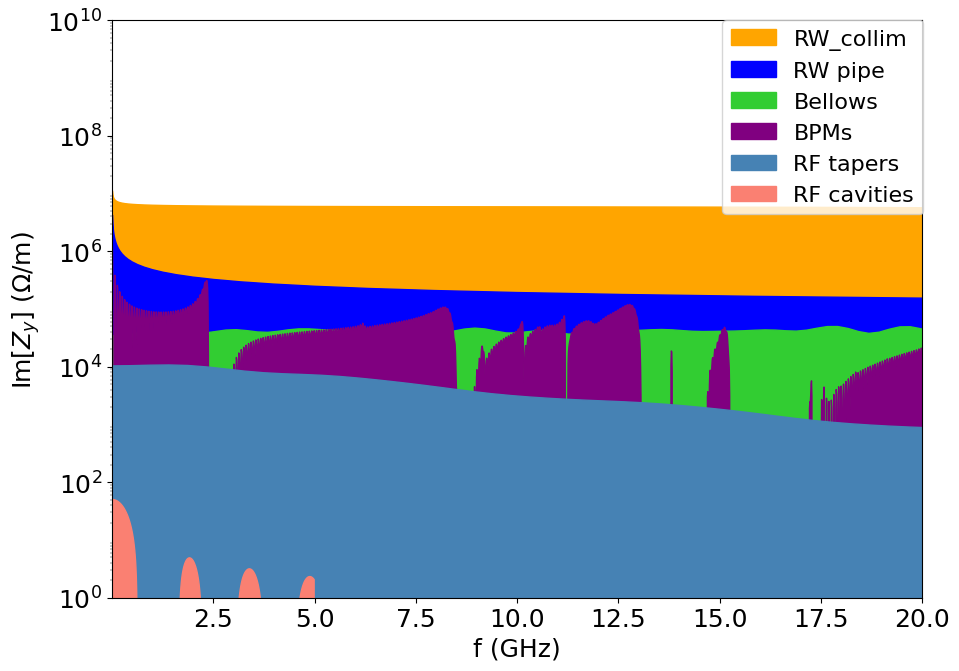

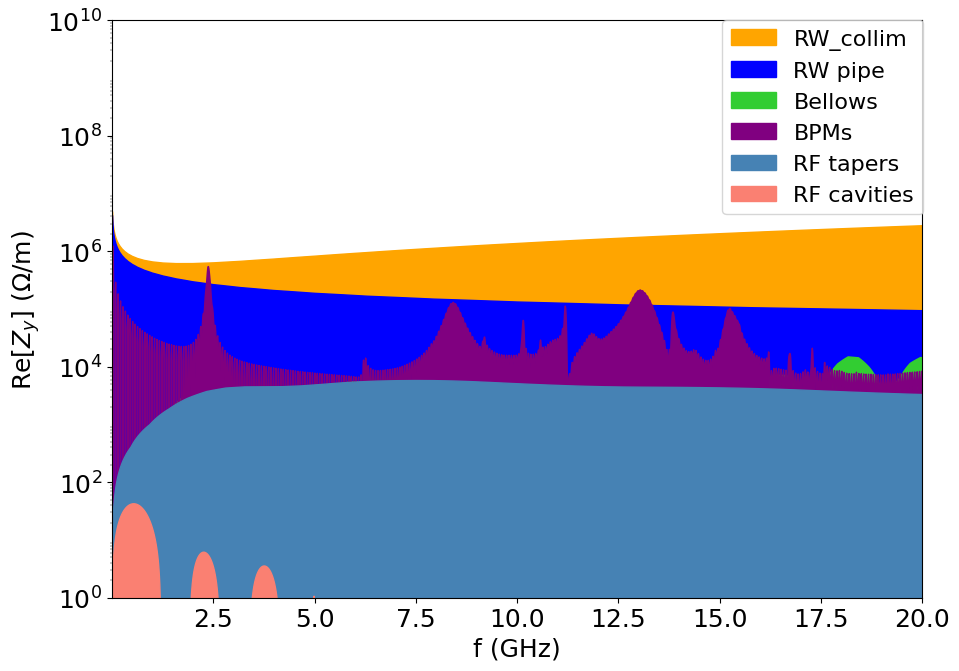

In [5]:
frequency, devices = read_impedance_devices(devices_folder, "dipy")

Z_contributions_dipy = [
    devices["coll"],
    devices["pipe_rw"],
    devices["bellows"],
    devices["bpm"],
    devices["rf_tapers"],
    devices["rf_cavities"]
]

colors = ['orange','blue','limegreen','purple','steelblue','salmon']
labels = ['RW_collim','RW pipe','Bellows','BPMs','RF tapers','RF cavities']


plot_stacked_impedance(frequency, Z_contributions_dipy, labels, colors,plane="dipy", part="imag")
plot_stacked_impedance(frequency, Z_contributions_dipy, labels, colors,plane="dipy", part="real")


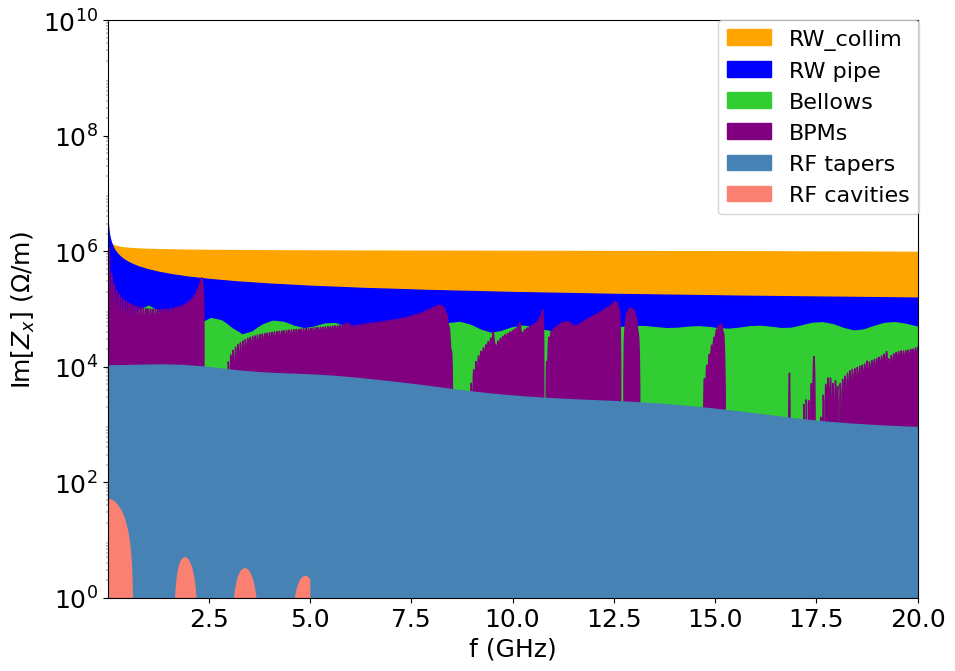

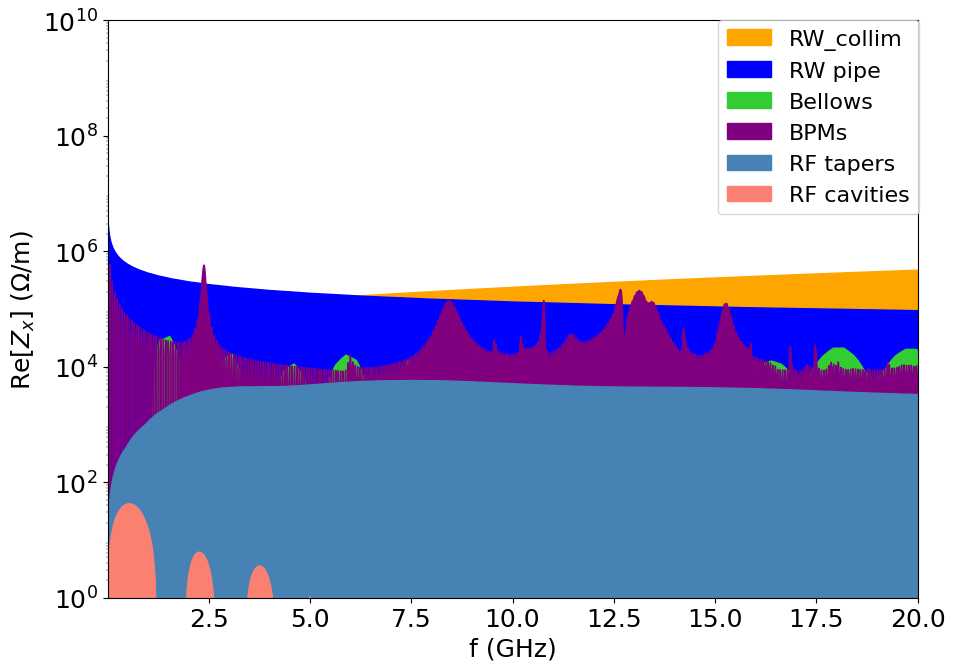

In [6]:
frequency, devices = read_impedance_devices(devices_folder, "dipx")
Z_contributions_dipx = [
    devices["coll"],
    devices["pipe_rw"],
    devices["bellows"],
    devices["bpm"],
    devices["rf_tapers"],
    devices["rf_cavities"]
]


plot_stacked_impedance(frequency, Z_contributions_dipx, labels, colors,plane="dipx", part="imag")
plot_stacked_impedance(frequency, Z_contributions_dipx, labels, colors,plane="dipx", part="real")

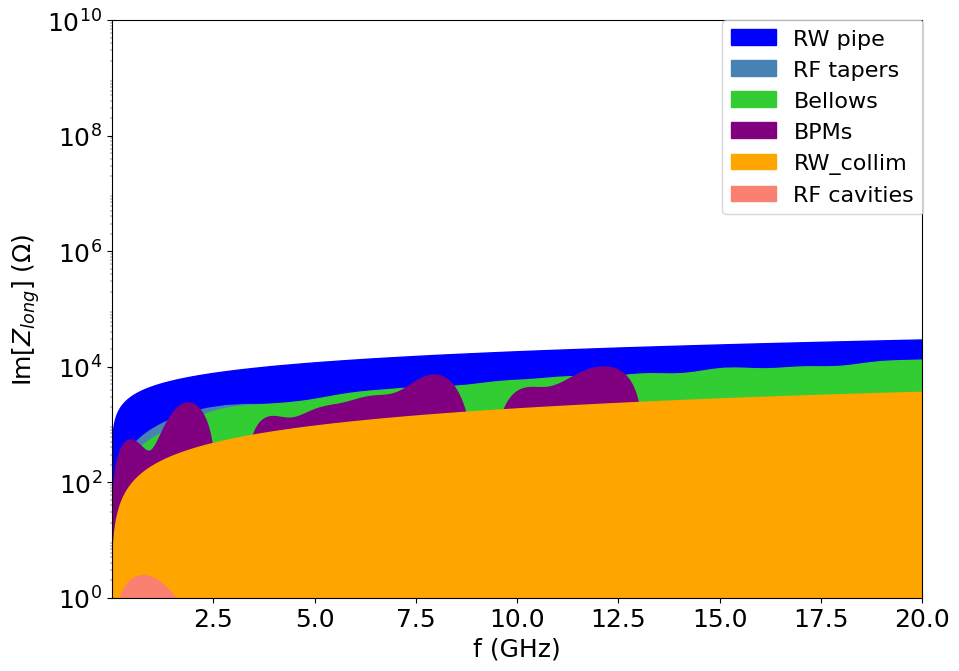

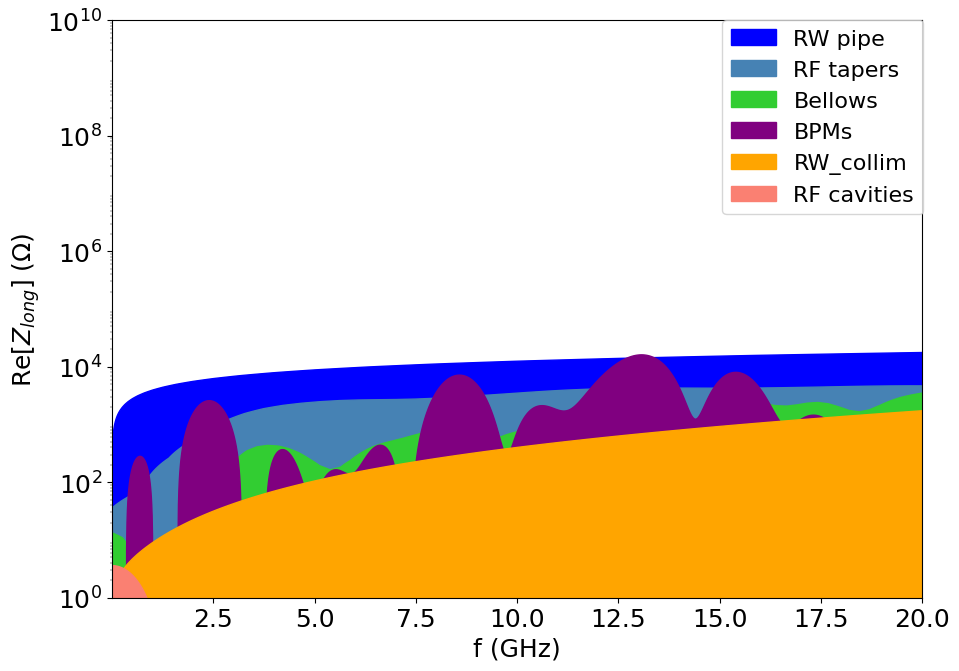

In [7]:
frequency, devices = read_impedance_devices(devices_folder, "long")

Z_contributions_long = [
    devices["pipe_rw"],
    devices["rf_tapers"],
    devices["bellows"],
    devices["bpm"],
    devices["coll"],
    devices["rf_cavities"]
]

colors = ['blue','steelblue','limegreen','purple','orange','salmon']
labels = ['RW pipe','RF tapers','Bellows','BPMs','RW_collim','RF cavities']

plot_stacked_impedance(frequency, Z_contributions_long, labels, colors,plane="long", part="imag")

plot_stacked_impedance(frequency, Z_contributions_long, labels, colors,plane="long", part="real")

### Plot of Total impedance 

In [8]:

def plot_dipoles(freq_x, Zx, freq_y, Zy, part, image_folder, scale="log"):
    """
    part  : 'real' or 'imag'
    scale : 'log' or 'linear'
    """

    plt.close('all')
    fig, ax = plt.subplots(figsize=(7,5))

    ax.set_xlabel('f (GHz)')

    # ---------- Select data ----------
    if part == "real":
        yx = Zx.real
        yy = Zy.real
        ylabel = r'Re[$Z_{dip}$] ($\Omega$/m)'
        name_part = "Re"

    elif part == "imag":
        yx = Zx.imag
        yy = Zy.imag
        ylabel = r'Im[$Z_{dip}$] ($\Omega$/m)'
        name_part = "Im"

    else:
        raise ValueError("part must be 'real' or 'imag'")

    ax.set_ylabel(ylabel)

    # ---------- Plot ----------
    ax.plot(freq_x, yx, lw=2, label=r'$Z_x$ dipole')
    ax.plot(freq_y, yy, lw=2, label=r'$Z_y$ dipole')

    ax.set_xlim(1e-3, 20)

    # ---------- Scale ----------
    if scale == "log":
        ax.set_yscale('log')
        ax.yaxis.set_major_locator(LogLocator(base=10.0))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1))

    elif scale == "linear":
        ax.set_yscale('linear')

    else:
        raise ValueError("scale must be 'log' or 'linear'")

    ax.set_xscale('linear')

    ax.legend()
    fig.subplots_adjust(left=0.12,right=0.93,bottom=0.15,top=0.92)

    filename = f"Z_total_dipole_{name_part}_{scale}.jpg"
    plt.savefig(image_folder / filename, dpi=300, bbox_inches='tight')

    plt.show()



def plot_longitudinal(freq, Z, part, image_folder, scale="log"):
    """
    part  : 'real' or 'imag'
    scale : 'log' or 'linear'
    """

    plt.close('all')
    fig, ax = plt.subplots(figsize=(7,5))

    ax.set_xlabel('f (GHz)')

    # ---------- Select data ----------
    if part == "real":
        y = Z.real
        ylabel = r'Re[$Z_{long}$] ($\Omega$)'
        name_part = "Re"

    elif part == "imag":
        y = Z.imag
        ylabel = r'Im[$Z_{long}$] ($\Omega$)'
        name_part = "Im"

    else:
        raise ValueError("part must be 'real' or 'imag'")

    ax.set_ylabel(ylabel)

    # ---------- Plot ----------
    ax.plot(freq, y, lw=2, label=r'$Z_{long}$')

    ax.set_xlim(1e-3, 20)

    # ---------- Scale ----------
    if scale == "log":
        ax.set_yscale('log')
        ax.yaxis.set_major_locator(LogLocator(base=10.0))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1))

    elif scale == "linear":
        ax.set_yscale('linear')

    else:
        raise ValueError("scale must be 'log' or 'linear'")

    ax.set_xscale('linear')

    ax.legend()
    fig.subplots_adjust(left=0.12,right=0.93,bottom=0.15,top=0.92)

    filename = f"Z_total_longitudinal_{name_part}_{scale}.jpg"
    plt.savefig(image_folder / filename, dpi=300, bbox_inches='tight')

    plt.show()

In [9]:
total_folder = Path.cwd().parent / "Impedances" / "Total"

freq_x, Zx_tot = read_total_impedance(total_folder, "dipx")
freq_y, Zy_tot = read_total_impedance(total_folder, "dipy")
freq_z, Zz_tot = read_total_impedance(total_folder, "long")

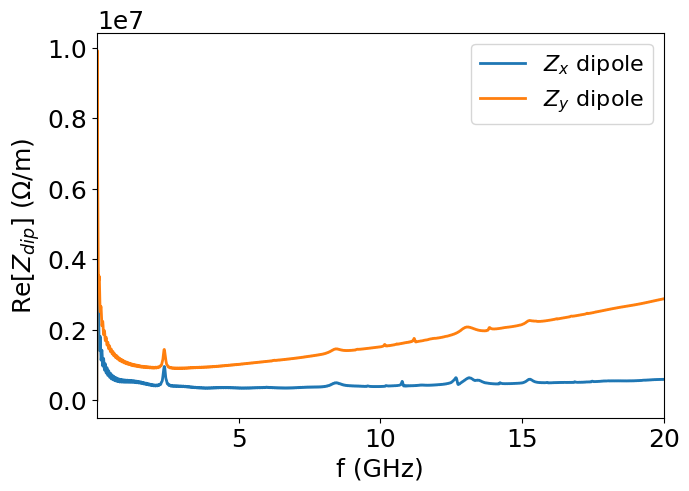

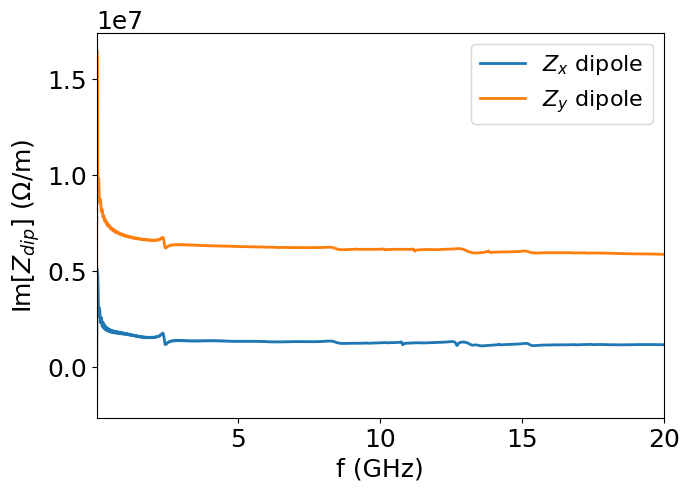

In [10]:
image_folder = Path.cwd().parent / "Plots" 
# REAL part
plot_dipoles(freq_x, Zx_tot, freq_y, Zy_tot,part="real", image_folder=image_folder, scale="linear")

# IMAG part
plot_dipoles(freq_x, Zx_tot, freq_y, Zy_tot,part="imag", image_folder=image_folder, scale="linear")

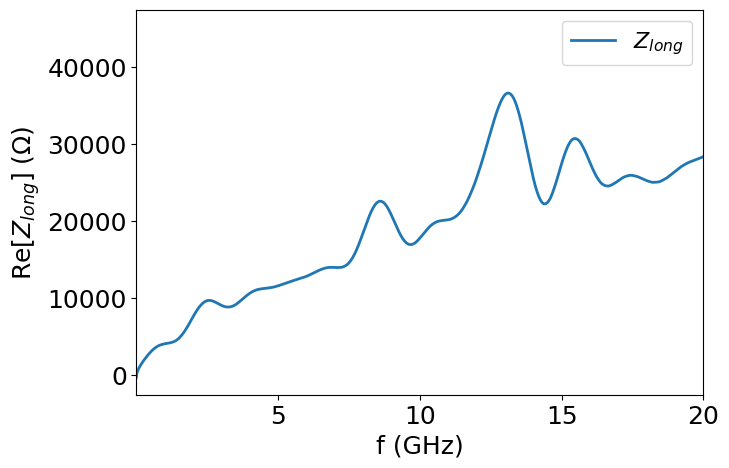

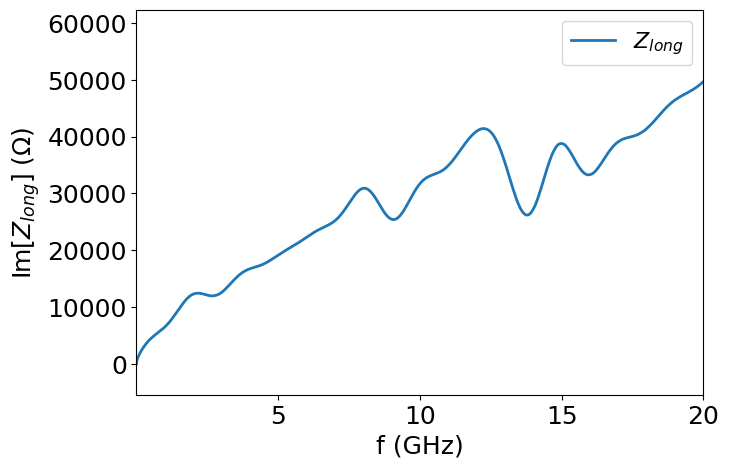

In [11]:
image_folder = Path.cwd().parent / "Plots" 
# REAL
plot_longitudinal(freq_z, Zz_tot,part="real", image_folder=image_folder, scale="linear")

# IMAG
plot_longitudinal(freq_z, Zz_tot,part="imag", image_folder=image_folder, scale="linear")